# Executive Summary

## Objective
This project analyzes sales performance data to identify revenue drivers, customer behavior patterns, and strategic opportunities to optimize business growth.

## Key Findings
- Total revenue reached approximately $1.88M during the observed period.
- Revenue demonstrates strong seasonality with significant growth in Q4.
- Sales are highly dependent on premium office equipment products.
- Customer revenue distribution is well diversified, reducing dependency risk.

## Business Impact
The analysis provides actionable insights to improve revenue stability, enhance customer value, and support data-driven strategic planning.

# 1. DATA PREPARATION

In [12]:
import pandas as pd

# Load data
url = 'https://raw.githubusercontent.com/Bintang04/Portofolio/main/sales_data.csv'
df = pd.read_csv(url)

df.columns = df.columns.str.strip()      # remove spaces
df.columns = df.columns.str.replace(';', '', regex=False)

#Hapus tanda ; dalam data sales
df['Sales'] = df['Sales'].astype(str).str.replace(';', '', regex=False)
#Ubah data sales menjadi numerik
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

df
# Cek missing value
df.isnull().sum()

# Drop missing jika sedikit
df = df.dropna()

# Ubah tipe tanggal
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)

# Buat kolom bulan & tahun
df['Month'] = df['Order_Date'].dt.month
df['Year'] = df['Order_Date'].dt.year

df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Month,Year
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,11,2017
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,6,2017
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,10,2016
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680,10,2016
6,7,CA-2015-115812,2015-06-09,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,6,2015


Raw data was prepared to ensure analytical reliability and consistency.
This process included handling missing values, validating data types, and standardizing date formats prior to analysis.

Proper data preparation ensures that subsequent insights accurately reflect business performance.

**Insight:**  
High-quality data preparation reduces analytical bias and improves decision-making accuracy, which is critical for business strategy evaluation.

# Business Questions

This analysis aims to answer key business questions that support data-driven decision making:

### Revenue Performance
- How has revenue evolved over time?
- Are there seasonal patterns affecting sales performance?
- Is revenue growth stable or driven by irregular spikes?

### Product Strategy
- Which product categories contribute the most to total revenue?
- Does the business rely too heavily on specific products?
- Where are diversification opportunities?

### Customer Insights
- Is revenue dependent on a small number of customers?
- How is revenue distributed across customer segments?
- Which customer groups present the greatest growth potential?

### Strategic Direction
- What operational or marketing actions can improve revenue stability?
- Where should the company focus future investment for sustainable growth?

In [13]:
# Key Business KPIs
total_revenue = df['Sales'].sum()
total_orders = df.shape[0]
total_customers = df['Customer_Name'].nunique()

print("Total Revenue:", round(total_revenue,2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)

Total Revenue: 1881017.54
Total Orders: 7627
Total Customers: 792


# 2. BUSINESS PERFORMACE ANALYSIS

In [14]:
#Hapus tanda ; dalam data sales
df['Sales'] = df['Sales'].astype(str).str.replace(';', '', regex=False)
#Ubah data sales menjadi numerik
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

total_revenue = df['Sales'].sum()
print(total_revenue)


#df['Sales'] = df['Sales'].str.replace(';', '', regex=False)
#df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

1881017.5365


## Revenue Analysis

During the observed period, the company generated approximately **$1.88 million** in total revenue, indicating strong commercial activity and market demand.

This metric establishes a baseline for evaluating growth trends, product performance, and customer contribution throughout the analysis.



**Business Insight:**  
Understanding total revenue provides strategic context for identifying whether performance improvements should focus on growth acceleration or revenue stabilization.

<Axes: xlabel='Month'>

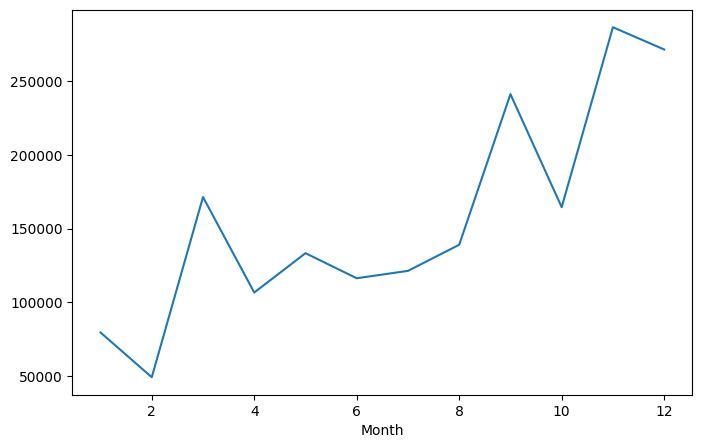

In [15]:
#Mencari Monthly Sales Trend

monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(kind='line', figsize=(8,5))

## Growth Analysis

Monthly revenue demonstrates a consistent upward trajectory, with accelerated growth observed during Q4. Revenue peaks in Month 11, suggesting strong seasonal demand patterns potentially linked to corporate purchasing cycles or year-end budget utilization.

Revenue volatility is visible in Months 2 and 10, indicating possible dependence on large, non-recurring transactions rather than predictable recurring sales streams.

**Business Insight:**  
Seasonal revenue concentration suggests an opportunity to align marketing campaigns, inventory planning, and operational capacity ahead of peak periods.

**Strategic Recommendation:**  
Develop recurring revenue models or subscription-based offerings to reduce volatility and improve revenue predictability.

## Category Analysis

To understand which business segments drive overall performance, revenue was aggregated by product category.
This analysis helps identify revenue concentration and potential diversification opportunities.

In [16]:

# Revenue (Sales) by Category
category_revenue = (
    df.groupby('Category')['Sales']
      .sum()
      .reset_index()
      .sort_values(by='Sales', ascending=False)
)

category_revenue['Contribution_%'] = (
    category_revenue['Sales'] /
    category_revenue['Sales'].sum()
) * 100

category_revenue

,Category,Sales,Contribution_%
2,Technology,797704.7750,42.408152
1,Office Supplies,576818.9010,30.665259
0,Furniture,506493.8605,26.926589


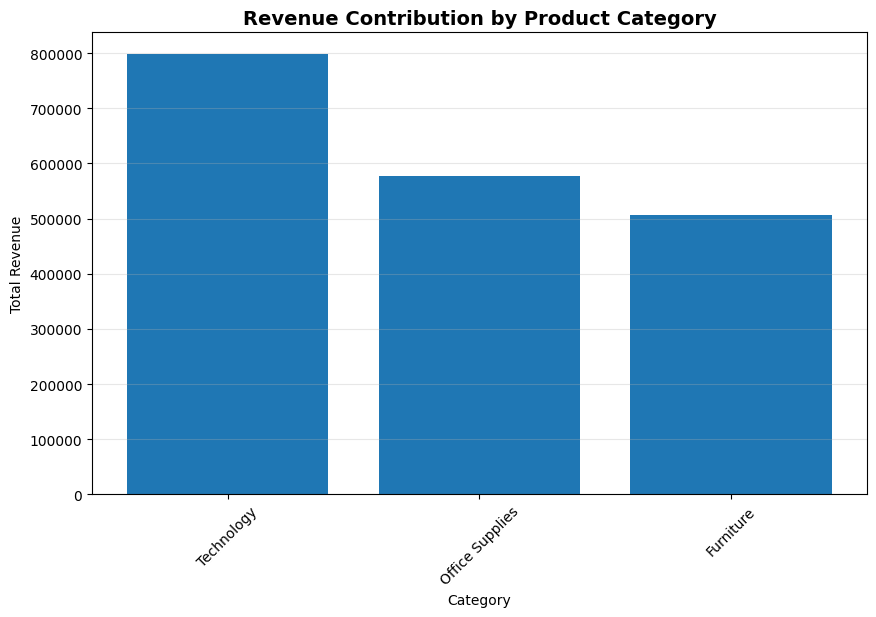

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(category_revenue['Category'],
        category_revenue['Sales'])

plt.title("Revenue Contribution by Product Category",
          fontsize=14,
          weight='bold')

plt.xlabel("Category")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

**Business Insight:**  
Revenue is concentrated within a limited number of product categories, indicating specialization in specific market segments.

**Strategic Implication:**  
Heavy dependence on one category may expose the business to market risk if demand declines.

**Recommendation:**  
Expanding complementary product categories could improve revenue diversification and long-term stability.

In [18]:
#Top 10 products

top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products

,Sales
Product_Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color,18374.895
GBC DocuBind P400 Electric Binding System,17965.068


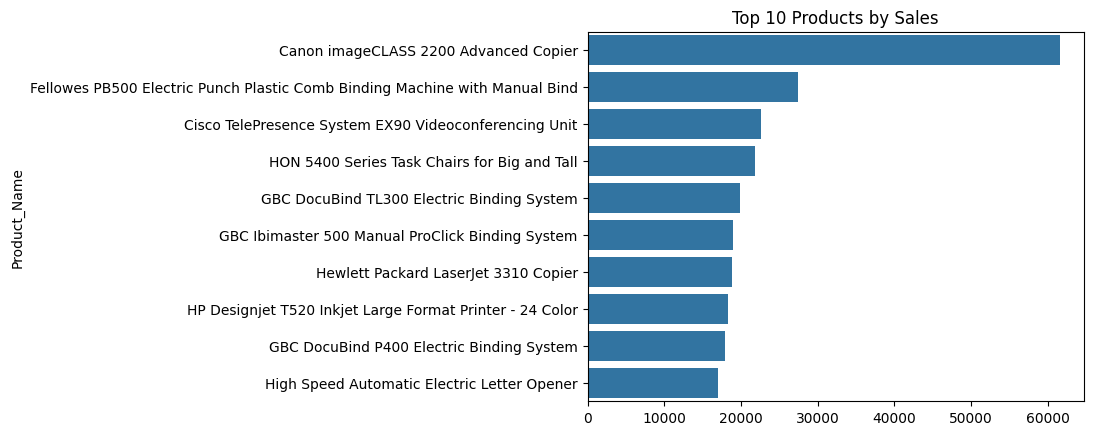

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Products by Sales")
plt.show()

## Product Analysis

Revenue distribution analysis reveals a strong concentration among a small number of premium office equipment products. The highest-performing product generates more than twice the revenue of the second-ranked product, highlighting significant product dependency.

Most top-performing products belong to the office equipment category, indicating that the company primarily serves corporate or institutional market segments.

**Business Insight:**  
High reliance on premium products increases revenue risk if demand shifts or competitors enter the market.

**Strategic Recommendation:**  
Diversify product offerings by introducing complementary mid-range products to stabilize revenue streams.

# CUSTOMER REVENUE INSIGHTS

In [20]:
#Customer Analysis
top_customers = df.groupby('Customer_Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_customers

,Sales
Customer_Name,
Sean Miller,24257.626
Tamara Chand,19017.848
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Ken Lonsdale,13940.717
Sanjit Chand,13701.674
Adrian Barton,13448.947
Hunter Lopez,12799.908
Sanjit Engle,11915.628


## Customer Revenue Distribution

The top 10 customers contribute less than 10% of total revenue, indicating a well-diversified customer portfolio. No single customer dominates overall sales, reducing concentration risk and improving revenue stability.

This distribution suggests a scalable business model supported by a broad customer base rather than dependency on key accounts.

**Business Insight:**  
A diversified customer base lowers financial risk but also highlights opportunities to increase customer lifetime value.

**Strategic Recommendation:**  
Implement targeted retention and upselling strategies to maximize revenue per high-value customer segment.

## Customer Segmentation Analysis
Customers are segmented based on their total revenue contribution to identify high-value customers and uncover opportunities for targeted business strategies.





In [22]:
# Calculate total sales per customer
customer_sales = (
    df.groupby('Customer_Name')['Sales']
      .sum()
      .reset_index()
      .sort_values(by='Sales', ascending=False)
)

customer_sales['Segment'] = pd.qcut(
    customer_sales['Sales'],
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

customer_sales.head()

,Customer_Name,Sales,Segment
685,Sean Miller,24257.626,High Value
729,Tamara Chand,19017.848,High Value
621,Raymond Buch,15117.339,High Value
756,Tom Ashbrook,14595.620,High Value
440,Ken Lonsdale,13940.717,High Value


In [23]:
segment_summary = (
    customer_sales.groupby('Segment')
    .agg(
        Number_of_Customers=('Customer_Name', 'count'),
        Total_Revenue=('Sales', 'sum')
    )
    .reset_index()
)

segment_summary['Revenue_%'] = (
    segment_summary['Total_Revenue'] /
    segment_summary['Total_Revenue'].sum()
) * 100

segment_summary

/tmp/ipython-input-1899/4127693552.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customer_sales.groupby('Segment')


,Segment,Number_of_Customers,Total_Revenue,Revenue_%
0,Low Value,264,1.408235e+05,7.486562
1,Medium Value,264,4.496238e+05,23.903224
2,High Value,264,1.290570e+06,68.610214


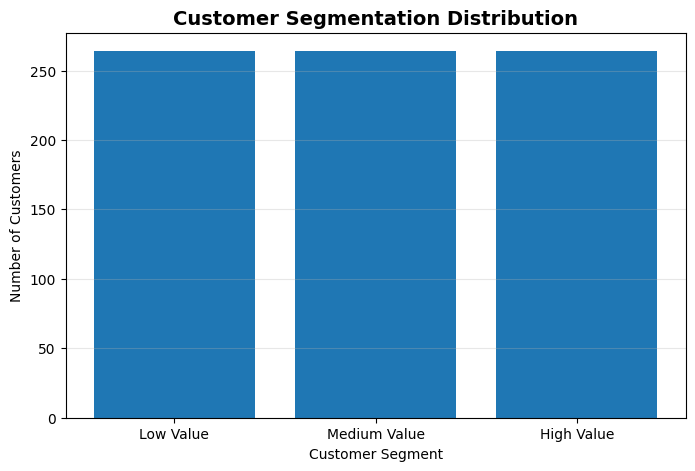

In [24]:
#Visualization
plt.figure(figsize=(8,5))

plt.bar(segment_summary['Segment'],
        segment_summary['Number_of_Customers'])

plt.title("Customer Segmentation Distribution",
          fontsize=14,
          weight='bold')

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.grid(axis='y', alpha=0.3)

plt.show()

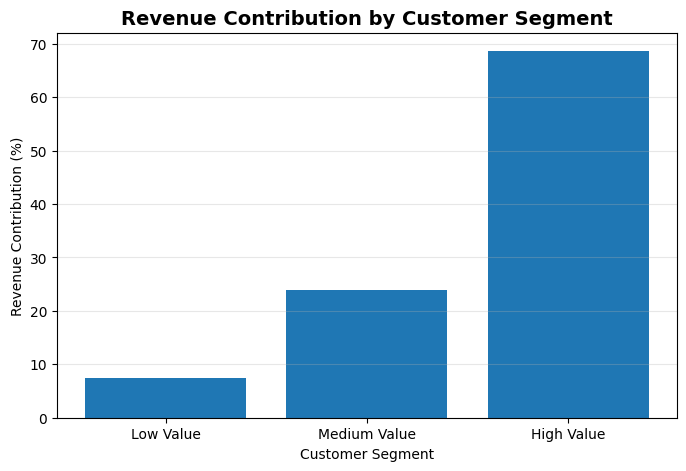

In [25]:
plt.figure(figsize=(8,5))

plt.bar(segment_summary['Segment'],
        segment_summary['Revenue_%'])

plt.title("Revenue Contribution by Customer Segment",
          fontsize=14,
          weight='bold')

plt.xlabel("Customer Segment")
plt.ylabel("Revenue Contribution (%)")

plt.grid(axis='y', alpha=0.3)

plt.show()

**Business Insight:**  
Revenue contribution is unevenly distributed across customer segments, where high-value customers generate a disproportionately large share of total revenue.

**Strategic Implication:**  
Business performance depends strongly on retaining and nurturing high-value customers.

**Recommendations:**  
- Implement loyalty and retention programs for high-value customers.
- Develop upselling strategies targeting medium-value customers.
- Use automated marketing campaigns to increase engagement among low-value customers.

# 3. Strategic Recommendations

Based on the analysis, the following actions are recommended:

### 1. Improve Revenue Stability
Introduce recurring purchasing programs or service-based offerings to reduce monthly volatility.

### 2. Reduce Product Dependency
Expand product diversification to minimize reliance on top-performing items.

### 3. Leverage Seasonal Demand
Increase marketing investment and inventory readiness before Q4 peak periods.

### 4. Increase Customer Lifetime Value
Develop loyalty programs and personalized upselling strategies.

In [27]:
summary_metrics = {
    "Total Revenue": df['Sales'].sum(),
    "Average Order Value": df['Sales'].mean(),
    "Total Customers": df['Customer_Name'].nunique(),
}

summary_metrics

{'Total Revenue': np.float64(1881017.5365),
 'Average Order Value': np.float64(246.62613563655432),
 'Total Customers': 792}

# Conclusion

This project analyzed sales performance to understand revenue dynamics, product dependency, and customer value distribution in order to support strategic business decision-making.

The analysis reveals that the business demonstrates strong overall revenue performance with clear seasonal growth patterns, particularly during Q4. While revenue growth is positive, fluctuations across months suggest opportunities to improve stability through recurring sales strategies.

Product analysis shows that revenue is concentrated within a limited number of high-performing office equipment products. Although this specialization supports strong performance, it introduces potential risk if market demand changes, highlighting the importance of diversification.

Customer analysis indicates a well-balanced customer base with low dependency on individual accounts. However, customer segmentation reveals that high-value customers contribute disproportionately to revenue, emphasizing the importance of retention and targeted engagement strategies.

Overall, the findings suggest that sustainable growth can be achieved by improving revenue predictability, diversifying product offerings, and increasing customer lifetime value through data-driven initiatives.

This project demonstrates how analytical insights can be translated into actionable business strategies that support long-term organizational performance.